# MO-IT134 – Milestone 2 Project Forecasting Model with DataViz

## Objective
This notebook extends the initial project forecasting model to predict the **next six months of company sales**.

## Goals
- Improve the original forecasting workflow
- Refine the feature set for better forecasting reliability
- Train and evaluate a time-series forecasting model
- Generate a six-month recursive forecast
- Create clear, readable, and business-friendly visualisations

## Key Refinements Applied
1. Removed features that may cause **data leakage** during future forecasting
2. Added **calendar-based time features**
3. Added **cyclical month encoding** using sine and cosine transformation
4. Added **trend-based features**
5. Used **TimeSeriesSplit** for better time-aware validation
6. Created a **recursive multi-step forecasting process** for six future months

## Dataset Used
- `monthly_sales_features.csv`

## Target Variable
- `monthly_sales`

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Load the Dataset

We begin by loading the pre-engineered monthly sales dataset generated from the initial forecasting model.

In [4]:
file_path = Path("monthly_sales_features.csv")
df = pd.read_csv(file_path)

# Convert year_month to datetime
df["year_month"] = pd.to_datetime(df["year_month"])

# Sort by date to preserve chronological order
df = df.sort_values("year_month").reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (43, 16)


,year_month,monthly_sales,txn_count,total_quantity,unique_products,avg_unit_price,year,month,quarter,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_6,sales_roll_mean_3,sales_roll_mean_6,sales_roll_std_3
0,2021-04-01,"59,946,030.62",38,473.00,19,"126,695.73",2021,4,2,"61,395,413.61","43,629,726.51","56,831,807.12","4,849,600.00","53,952,315.75","44,154,287.46","9,226,240.43"
1,2021-05-01,"51,639,251.82",36,416.00,19,"129,656.99",2021,5,2,"59,946,030.62","61,395,413.61","43,629,726.51","60,165,285.88","54,990,390.25","53,337,025.90","9,865,276.90"
2,2021-06-01,"60,673,564.96",39,434.00,16,"138,791.84",2021,6,2,"51,639,251.82","59,946,030.62","61,395,413.61","38,053,891.64","57,660,232.02","51,916,020.22","5,264,440.11"
3,2021-07-01,"54,782,210.01",37,430.00,17,"132,002.95",2021,7,3,"60,673,564.96","51,639,251.82","59,946,030.62","56,831,807.12","57,419,615.80","55,685,965.77","5,019,141.59"
4,2021-08-01,"52,383,097.37",34,382.00,18,"133,737.35",2021,8,3,"54,782,210.01","60,673,564.96","51,639,251.82","43,629,726.51","55,698,342.27","55,344,366.26","4,586,303.22"


## 2. Inspect the Dataset

We check the structure, data types, missing values, and date coverage before modelling.

In [6]:
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDate range:")
print("Start:", df["year_month"].min())
print("End:", df["year_month"].max())

Columns:
['year_month', 'monthly_sales', 'txn_count', 'total_quantity', 'unique_products', 'avg_unit_price', 'year', 'month', 'quarter', 'sales_lag_1', 'sales_lag_2', 'sales_lag_3', 'sales_lag_6', 'sales_roll_mean_3', 'sales_roll_mean_6', 'sales_roll_std_3']

Data types:
year_month           datetime64[ns]
monthly_sales               float64
txn_count                     int64
total_quantity              float64
unique_products               int64
avg_unit_price              float64
year                          int64
month                         int64
quarter                       int64
sales_lag_1                 float64
sales_lag_2                 float64
sales_lag_3                 float64
sales_lag_6                 float64
sales_roll_mean_3           float64
sales_roll_mean_6           float64
sales_roll_std_3            float64
dtype: object

Missing values:
year_month           0
monthly_sales        0
txn_count            0
total_quantity       0
unique_products      0
avg_un

## 3. Initial Sales Trend Visualisation

This chart shows the historical monthly sales pattern across time.

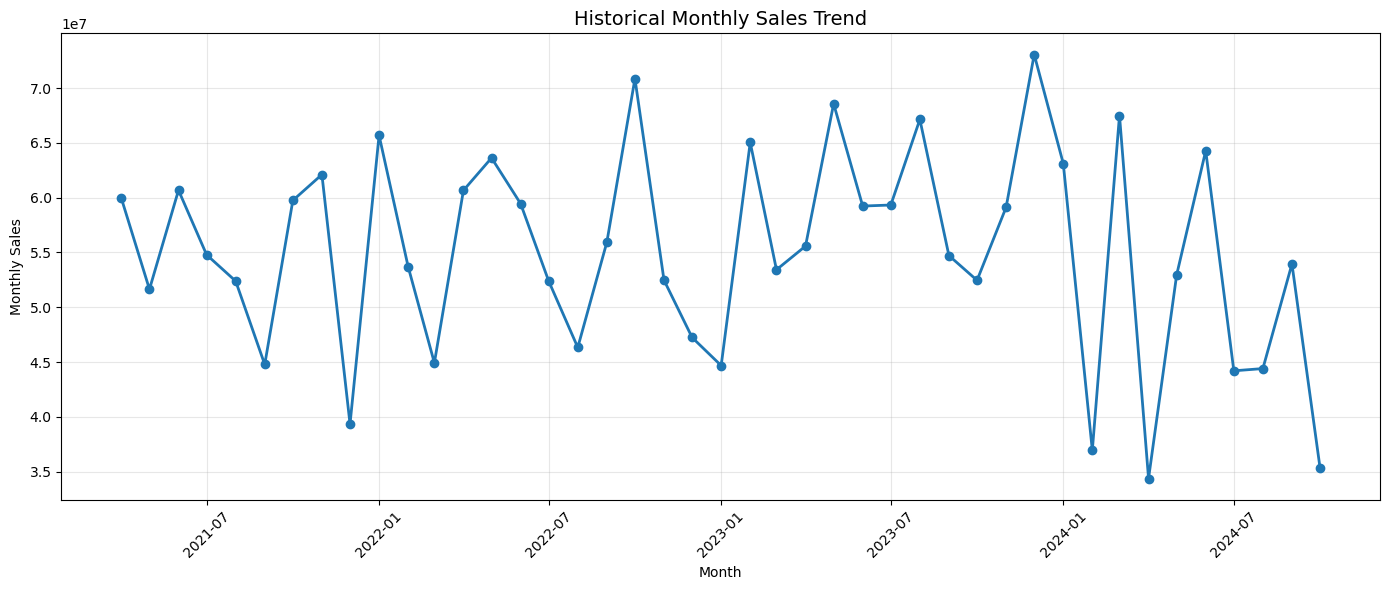

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(df["year_month"], df["monthly_sales"], marker="o", linewidth=2)
plt.title("Historical Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Monthly Sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Model Refinement Strategy

Although the original dataset contains variables such as:
- `txn_count`
- `total_quantity`
- `unique_products`
- `avg_unit_price`

these values are typically **not known in advance for future months**.

Using them directly in forecasting can create a form of **data leakage**, because the model would rely on information that would not yet exist when predicting future sales.

### Refinement Applied
For a more realistic forecasting model, we will use only features that are available at forecast time:
- calendar features
- lag features
- rolling statistics
- cyclical month features
- trend index

In [9]:
# Create a working copy
model_df = df.copy()

# Add trend index
model_df["time_idx"] = np.arange(len(model_df))

# Add cyclical month encoding
model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

# Add simple lag-difference features
model_df["lag_diff_1_2"] = model_df["sales_lag_1"] - model_df["sales_lag_2"]
model_df["lag_diff_2_3"] = model_df["sales_lag_2"] - model_df["sales_lag_3"]

# Keep only forecast-safe features
feature_cols = [
    "year",
    "month",
    "quarter",
    "time_idx",
    "month_sin",
    "month_cos",
    "sales_lag_1",
    "sales_lag_2",
    "sales_lag_3",
    "sales_lag_6",
    "sales_roll_mean_3",
    "sales_roll_mean_6",
    "sales_roll_std_3",
    "lag_diff_1_2",
    "lag_diff_2_3"
]

# Drop rows with missing values created by lag/rolling features
model_df = model_df.dropna(subset=feature_cols + ["monthly_sales"]).reset_index(drop=True)

print("Refined modelling dataset shape:", model_df.shape)
model_df.head()

Refined modelling dataset shape: (43, 21)


,year_month,monthly_sales,txn_count,total_quantity,unique_products,avg_unit_price,year,month,quarter,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_6,sales_roll_mean_3,sales_roll_mean_6,sales_roll_std_3,time_idx,month_sin,month_cos,lag_diff_1_2,lag_diff_2_3
0,2021-04-01,"59,946,030.62",38,473.00,19,"126,695.73",2021,4,2,"61,395,413.61","43,629,726.51","56,831,807.12","4,849,600.00","53,952,315.75","44,154,287.46","9,226,240.43",0,0.87,-0.50,"17,765,687.10","-13,202,080.62"
1,2021-05-01,"51,639,251.82",36,416.00,19,"129,656.99",2021,5,2,"59,946,030.62","61,395,413.61","43,629,726.51","60,165,285.88","54,990,390.25","53,337,025.90","9,865,276.90",1,0.50,-0.87,"-1,449,382.99","17,765,687.10"
2,2021-06-01,"60,673,564.96",39,434.00,16,"138,791.84",2021,6,2,"51,639,251.82","59,946,030.62","61,395,413.61","38,053,891.64","57,660,232.02","51,916,020.22","5,264,440.11",2,0.00,-1.00,"-8,306,778.80","-1,449,382.99"
3,2021-07-01,"54,782,210.01",37,430.00,17,"132,002.95",2021,7,3,"60,673,564.96","51,639,251.82","59,946,030.62","56,831,807.12","57,419,615.80","55,685,965.77","5,019,141.59",3,-0.50,-0.87,"9,034,313.13","-8,306,778.80"
4,2021-08-01,"52,383,097.37",34,382.00,18,"133,737.35",2021,8,3,"54,782,210.01","60,673,564.96","51,639,251.82","43,629,726.51","55,698,342.27","55,344,366.26","4,586,303.22",4,-0.87,-0.50,"-5,891,354.94","9,034,313.13"


## 5. Correlation Heatmap

This heatmap helps identify how the engineered features relate to monthly sales and to one another.

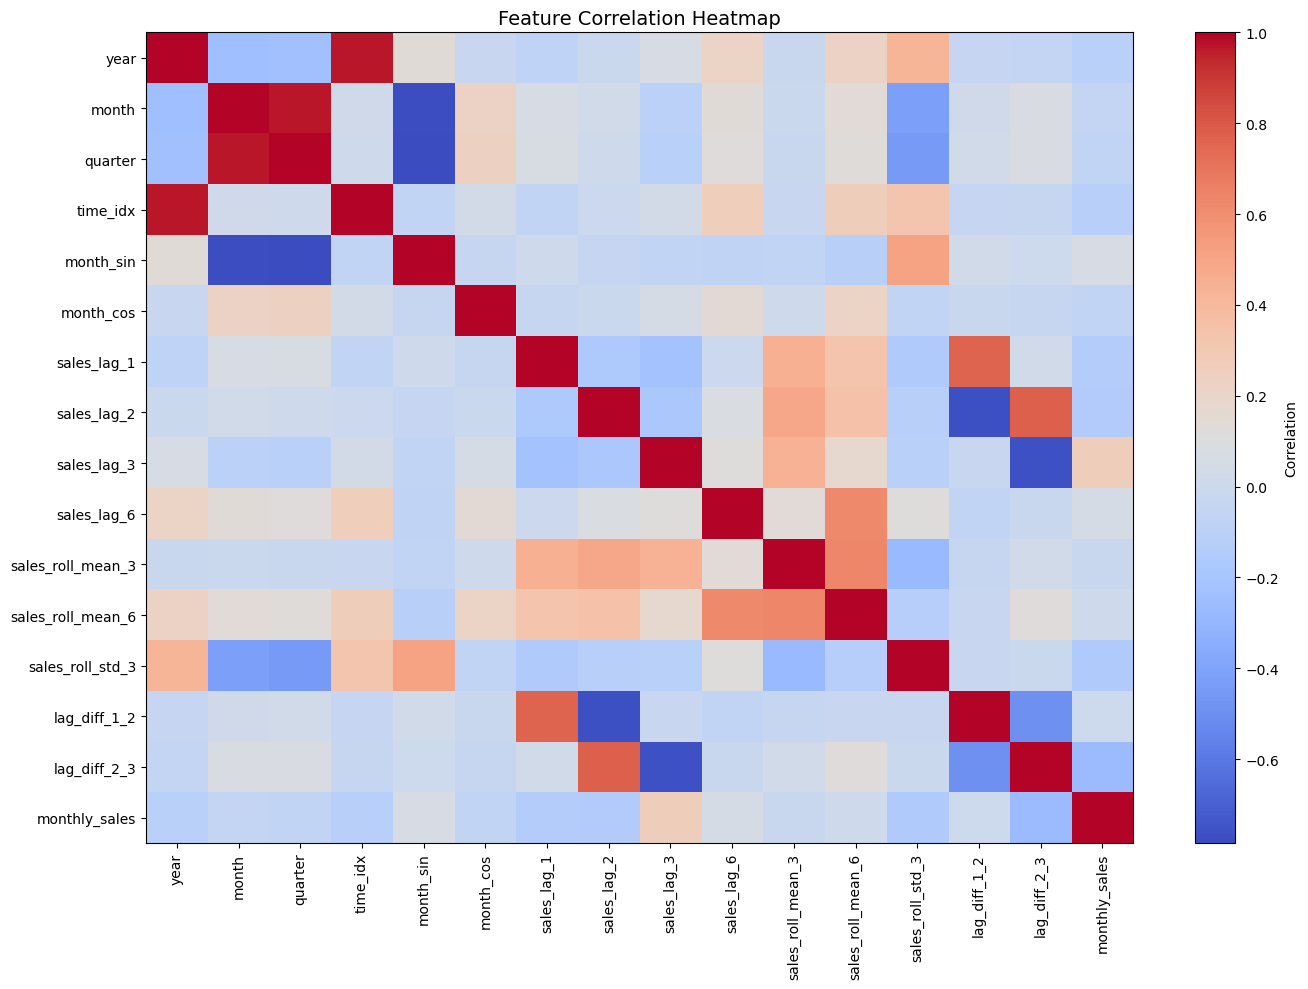

In [10]:
corr_cols = feature_cols + ["monthly_sales"]
corr_matrix = model_df[corr_cols].corr()

plt.figure(figsize=(14, 10))
plt.imshow(corr_matrix, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)

plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Seasonal Pattern by Month

This visualisation shows how average sales vary by calendar month.
It helps support whether seasonality exists in the data.

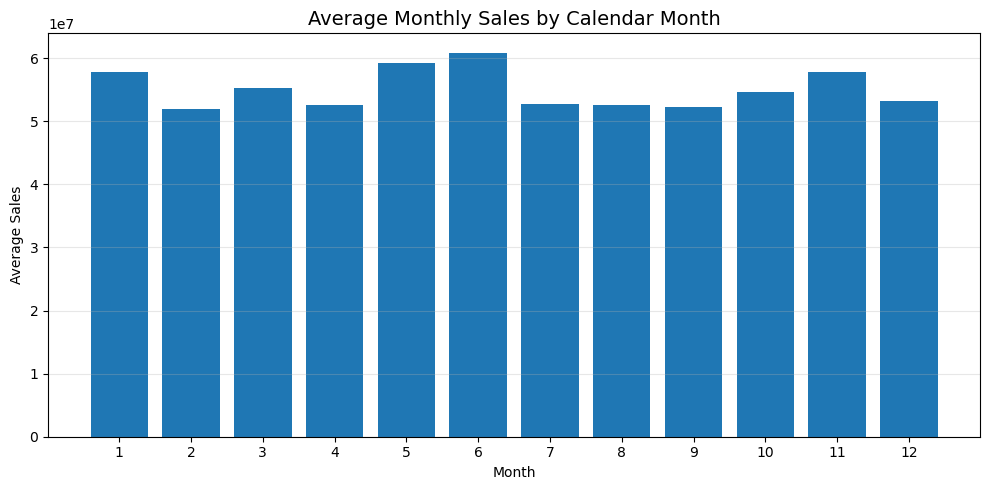

In [11]:
monthly_avg = model_df.groupby("month")["monthly_sales"].mean()

plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values)
plt.title("Average Monthly Sales by Calendar Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.xticks(monthly_avg.index)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Train-Test Split

To preserve the chronological order of time-series data, we use the most recent months as the test set.

### Split Strategy
- Training set: earlier months
- Test set: last 6 observed months

In [12]:
test_months = 6

train_df = model_df.iloc[:-test_months].copy()
test_df = model_df.iloc[-test_months:].copy()

X_train = train_df[feature_cols]
y_train = train_df["monthly_sales"]

X_test = test_df[feature_cols]
y_test = test_df["monthly_sales"]

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))
print("\nTrain period:", train_df["year_month"].min(), "to", train_df["year_month"].max())
print("Test period:", test_df["year_month"].min(), "to", test_df["year_month"].max())

Training rows: 37
Testing rows: 6

Train period: 2021-04-01 00:00:00 to 2024-04-01 00:00:00
Test period: 2024-05-01 00:00:00 to 2024-10-01 00:00:00


## 8. Baseline Model

Before building a machine learning model, we create a simple baseline forecast.

### Baseline Approach
Use the previous month’s sales as the prediction for the next month.

This helps us compare whether the machine learning model actually improves forecasting performance.

In [13]:
baseline_pred = X_test["sales_lag_1"].values

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = rmse(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Performance")
print(f"MAE : {baseline_mae:,.2f}")
print(f"RMSE: {baseline_rmse:,.2f}")
print(f"R²  : {baseline_r2:,.4f}")

Baseline Performance
MAE : 13,057,135.11
RMSE: 14,799,745.16
R²  : -1.6060


## 9. Hyperparameter Tuning with TimeSeriesSplit

We use **TimeSeriesSplit** instead of random cross-validation so that model validation respects chronological order.

### Model Chosen
- Random Forest Regressor

### Why Random Forest?
- Handles nonlinear relationships well
- Works effectively with small-to-medium tabular datasets
- Captures interactions among lag and rolling features
- Does not require strict data scaling

In [16]:
tscv = TimeSeriesSplit(n_splits=4)

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}


## 10. Evaluate the Tuned Model

Now we evaluate the tuned Random Forest model on the test set.

In [17]:
rf_pred = best_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = rmse(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Tuned Random Forest Performance")
print(f"MAE : {rf_mae:,.2f}")
print(f"RMSE: {rf_rmse:,.2f}")
print(f"R²  : {rf_r2:,.4f}")

Tuned Random Forest Performance
MAE : 8,864,085.85
RMSE: 11,641,160.29
R²  : -0.6123


## 11. Baseline vs Tuned Model Comparison

This table shows whether the refined forecasting model performs better than the naive baseline.

In [18]:
comparison_df = pd.DataFrame({
    "Model": ["Baseline (Lag-1)", "Tuned Random Forest"],
    "MAE": [baseline_mae, rf_mae],
    "RMSE": [baseline_rmse, rf_rmse],
    "R2": [baseline_r2, rf_r2]
})

comparison_df

,Model,MAE,RMSE,R2
0,Baseline (Lag-1),"13,057,135.11","14,799,745.16",-1.61
1,Tuned Random Forest,"8,864,085.85","11,641,160.29",-0.61


## 12. Actual vs Predicted Sales on the Test Set

This chart compares the actual sales values with the model’s predictions for the most recent observed months.

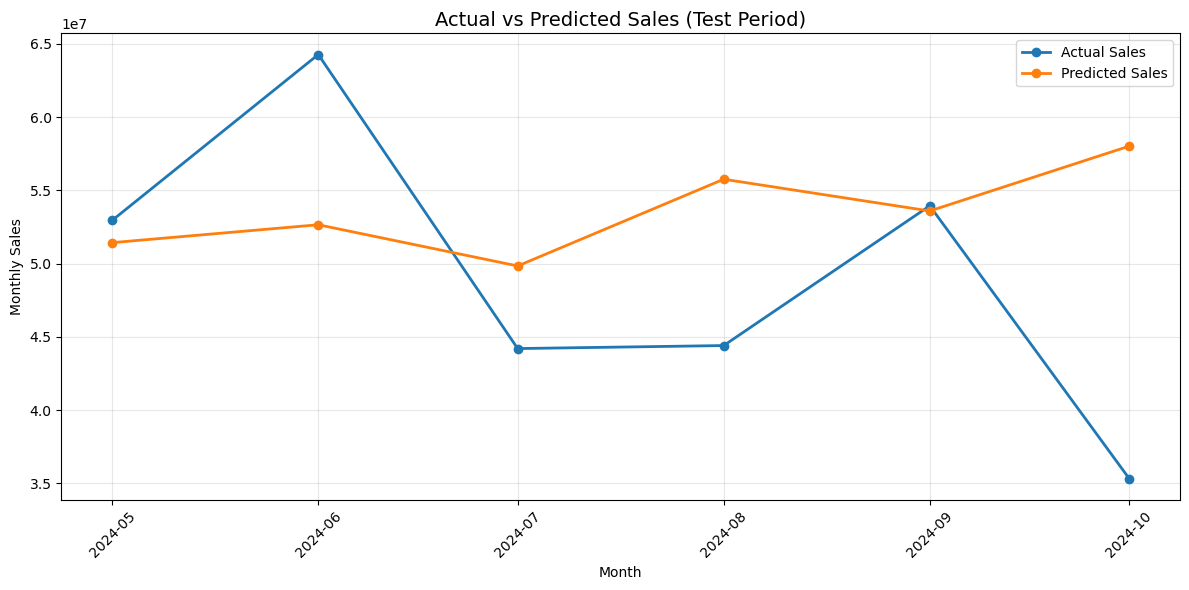

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(test_df["year_month"], y_test.values, marker="o", linewidth=2, label="Actual Sales")
plt.plot(test_df["year_month"], rf_pred, marker="o", linewidth=2, label="Predicted Sales")

plt.title("Actual vs Predicted Sales (Test Period)", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Monthly Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Feature Importance

Feature importance helps explain which variables the model relied on most when predicting monthly sales.

In [20]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
14,lag_diff_2_3,0.22
3,time_idx,0.13
6,sales_lag_1,0.09
7,sales_lag_2,0.08
12,sales_roll_std_3,0.07
10,sales_roll_mean_3,0.06
8,sales_lag_3,0.06
11,sales_roll_mean_6,0.05
5,month_cos,0.05
13,lag_diff_1_2,0.04


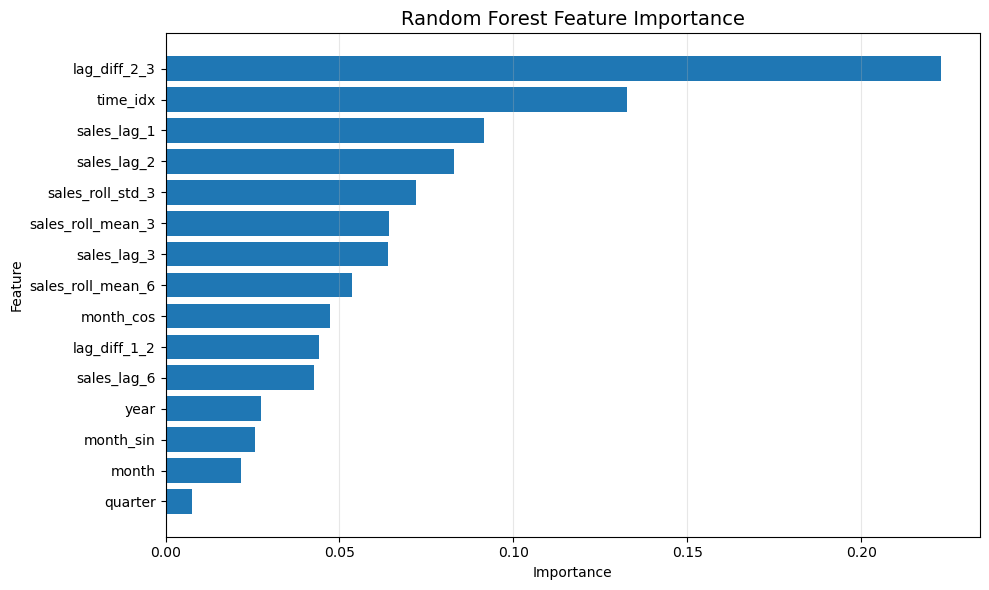

In [21]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 14. Retrain Model on Full Historical Data

After evaluation, we retrain the tuned model using all available historical data before generating future forecasts.

X_full = model_df[feature_cols]
y_full = model_df["monthly_sales"]

final_model = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42
)

final_model.fit(X_full, y_full)

## 15. Forecast the Next Six Months

We now produce a **recursive six-month forecast**.

### Recursive Forecasting Logic
For each future month:
1. Create the next month’s calendar values
2. Update lag features using the most recent known or predicted sales
3. Recompute rolling features
4. Predict the next month
5. Append the prediction into history
6. Repeat until six months are generated

In [25]:
forecast_horizon = 6
future_forecasts = []

# Start with the original monthly sales history
history = model_df[["year_month", "monthly_sales"]].copy().reset_index(drop=True)

for step in range(1, forecast_horizon + 1):
    next_month = history["year_month"].max() + pd.offsets.MonthBegin(1)
    
    # Calendar features
    year = next_month.year
    month = next_month.month
    quarter = next_month.quarter
    time_idx = len(history)
    
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    
    # Lag features from history
    sales_lag_1 = history["monthly_sales"].iloc[-1]
    sales_lag_2 = history["monthly_sales"].iloc[-2]
    sales_lag_3 = history["monthly_sales"].iloc[-3]
    sales_lag_6 = history["monthly_sales"].iloc[-6]
    
    # Rolling features
    sales_roll_mean_3 = history["monthly_sales"].tail(3).mean()
    sales_roll_mean_6 = history["monthly_sales"].tail(6).mean()
    sales_roll_std_3 = history["monthly_sales"].tail(3).std()
    
    # Difference features
    lag_diff_1_2 = sales_lag_1 - sales_lag_2
    lag_diff_2_3 = sales_lag_2 - sales_lag_3
    
    # Create feature row
    future_row = pd.DataFrame([{
        "year": year,
        "month": month,
        "quarter": quarter,
        "time_idx": time_idx,
        "month_sin": month_sin,
        "month_cos": month_cos,
        "sales_lag_1": sales_lag_1,
        "sales_lag_2": sales_lag_2,
        "sales_lag_3": sales_lag_3,
        "sales_lag_6": sales_lag_6,
        "sales_roll_mean_3": sales_roll_mean_3,
        "sales_roll_mean_6": sales_roll_mean_6,
        "sales_roll_std_3": sales_roll_std_3,
        "lag_diff_1_2": lag_diff_1_2,
        "lag_diff_2_3": lag_diff_2_3
    }])
    
    # Predict
    forecast_value = final_model.predict(future_row[feature_cols])[0]
    
    # Store forecast
    future_forecasts.append({
        "year_month": next_month,
        "forecast_sales": forecast_value
    })
    
    # Append to history so it can be used for next step
    history = pd.concat([
        history,
        pd.DataFrame([{
            "year_month": next_month,
            "monthly_sales": forecast_value
        }])
    ], ignore_index=True)

future_df = pd.DataFrame(future_forecasts)
future_df

,year_month,forecast_sales
0,2024-11-01,"47,469,941.07"
1,2024-12-01,"54,715,464.85"
2,2025-01-01,"45,387,671.92"
3,2025-02-01,"50,864,373.75"
4,2025-03-01,"55,444,276.86"
5,2025-04-01,"49,960,558.32"


## 16. Forecast Results Table

The following table contains the projected monthly sales for the next six months.

In [27]:
future_df["forecast_sales"] = future_df["forecast_sales"].round(2)
future_df

,year_month,forecast_sales
0,2024-11-01,"47,469,941.07"
1,2024-12-01,"54,715,464.85"
2,2025-01-01,"45,387,671.92"
3,2025-02-01,"50,864,373.75"
4,2025-03-01,"55,444,276.86"
5,2025-04-01,"49,960,558.32"


## 17. Historical Sales and Six-Month Forecast

This visualisation combines:
- historical observed sales
- future predicted sales

to clearly communicate the expected direction of company sales over the next six months.

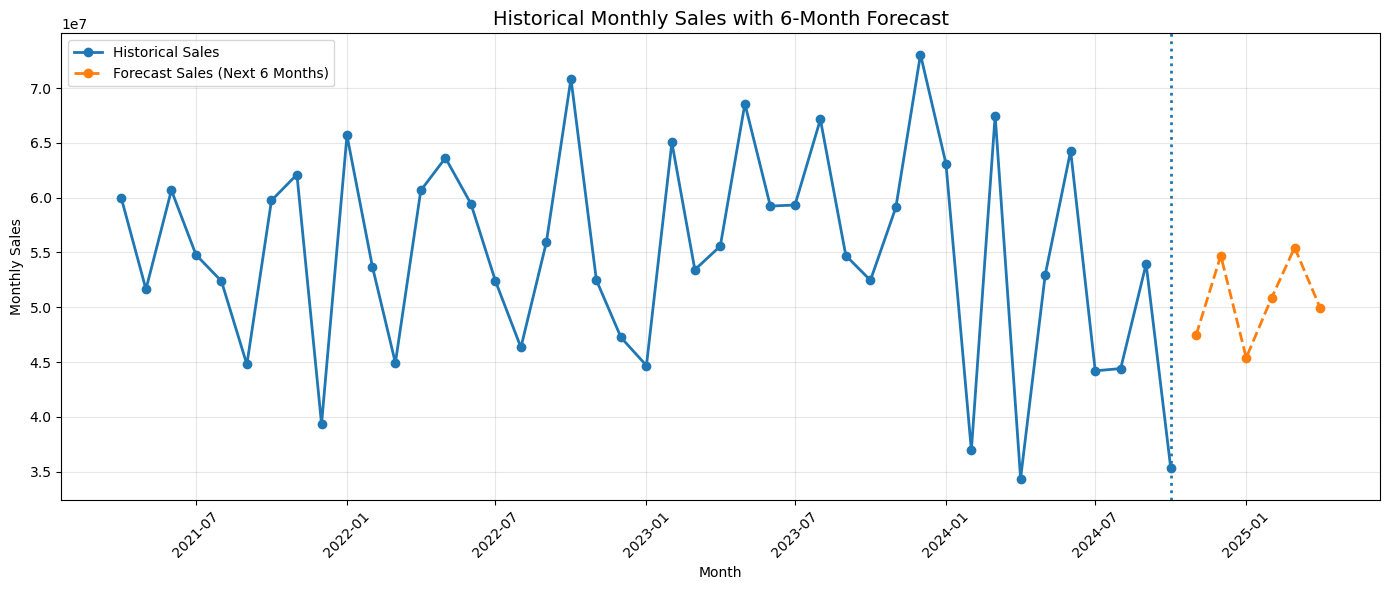

In [28]:
plt.figure(figsize=(14, 6))

# Historical actual sales
plt.plot(
    model_df["year_month"],
    model_df["monthly_sales"],
    marker="o",
    linewidth=2,
    label="Historical Sales"
)

# Forecast sales
plt.plot(
    future_df["year_month"],
    future_df["forecast_sales"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Forecast Sales (Next 6 Months)"
)

# Add vertical line to separate historical and future periods
plt.axvline(model_df["year_month"].max(), linestyle=":", linewidth=2)

plt.title("Historical Monthly Sales with 6-Month Forecast", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Monthly Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Forecast Distribution Visualisation

This bar chart presents the forecasted values month by month for easier business interpretation.

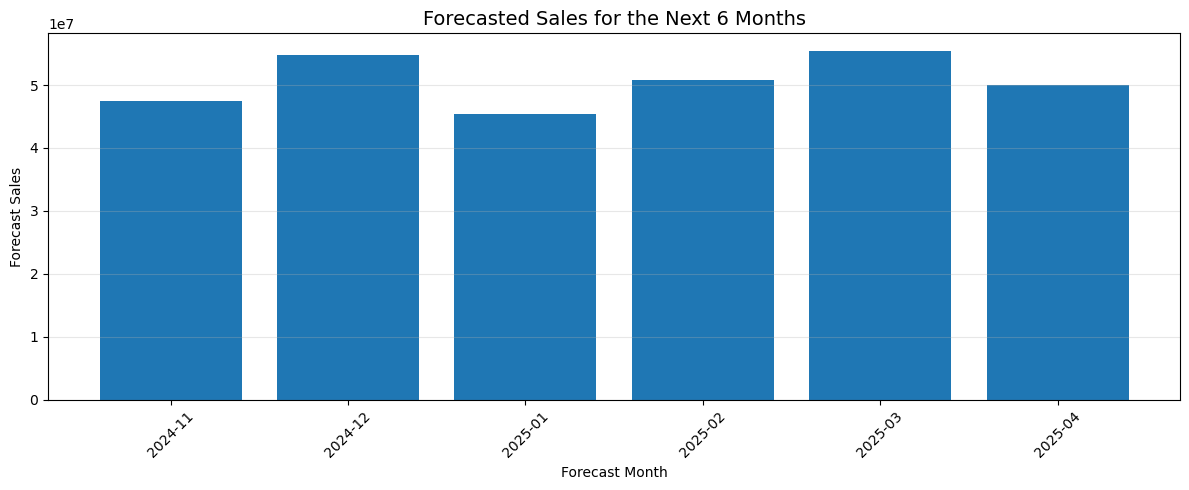

In [29]:
plt.figure(figsize=(12, 5))
plt.bar(future_df["year_month"].dt.strftime("%Y-%m"), future_df["forecast_sales"])

plt.title("Forecasted Sales for the Next 6 Months", fontsize=14)
plt.xlabel("Forecast Month")
plt.ylabel("Forecast Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 19. Residual Analysis on Test Set

Residuals help us understand how far the predictions are from the actual values.
A good model should show relatively small and balanced residuals.

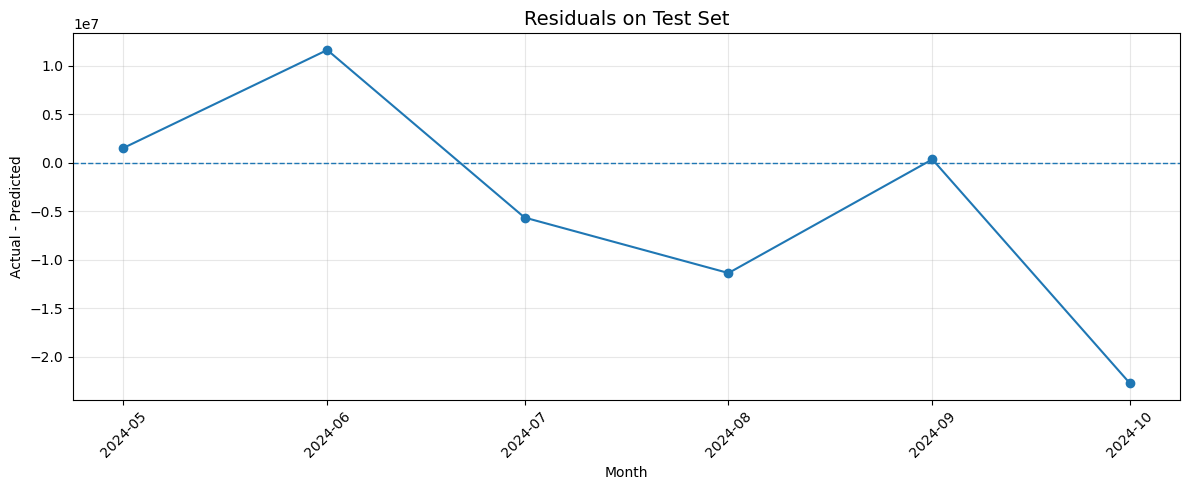

In [31]:
residuals = y_test.values - rf_pred

plt.figure(figsize=(12, 5))
plt.plot(test_df["year_month"], residuals, marker="o")
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Residuals on Test Set", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Actual - Predicted")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 20. Save the Forecast Output

The final six-month forecast is exported to a CSV file for reporting and submission.

In [32]:
output_path = Path("sales_forecast_next_6_months.csv")
future_df.to_csv(output_path, index=False)

print("Saved file:", output_path.resolve())

Saved file: /Users/tris/2025 Developments/Machine Learning and Predictive Analysis/Milestone 2/sales_forecast_next_6_months.csv


## 21. Combined Test Performance and Future Forecast

This chart connects the last observed actual values, the test-period predictions, and the six-month future forecast in a single view.

Text(0.5, 1.0, 'Historical Sales, Test Predictions, and 6 Months Forecast')

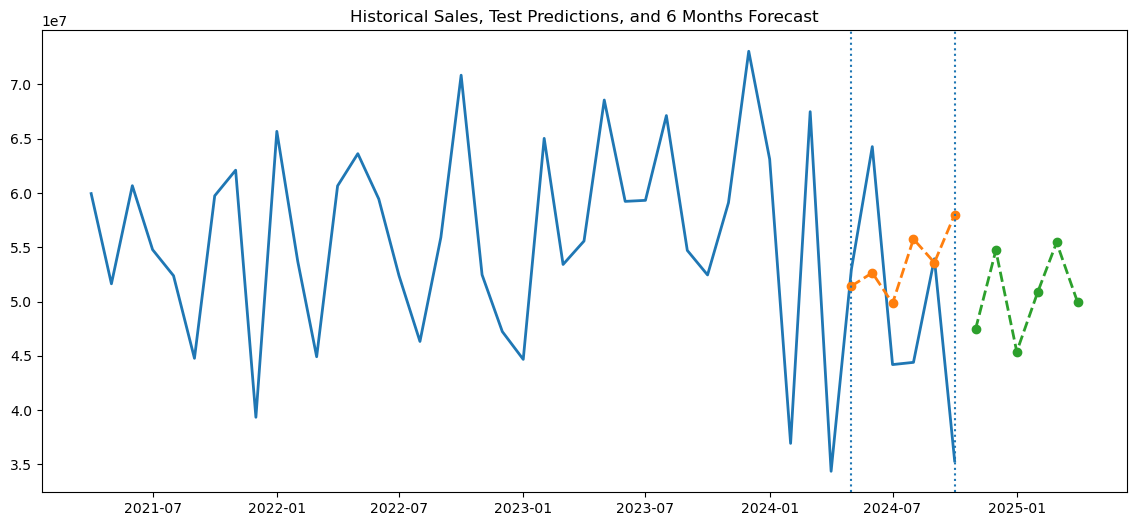

In [35]:
plt.figure(figsize=(14, 6))

# Full actual history
plt.plot(model_df["year_month"], model_df["monthly_sales"], label="Actual Historical Sales", linewidth=2)

# Test predictions
plt.plot(test_df["year_month"], rf_pred, marker="o", linestyle="--", linewidth=2, label="Test Predictions")

# Future forecast
plt.plot(future_df["year_month"], future_df["forecast_sales"], marker="o", linestyle="--", linewidth=2, label="Future Forecast")

plt.axvline(test_df["year_month"].min(), linestyle=":", linewidth=1.5)
plt.axvline(model_df["year_month"].max(), linestyle=":", linewidth=1.5)

plt.title("Historical Sales, Test Predictions, and 6 Months Forecast")

# Final Interpretation and Findings

## Summary of Work Completed
This notebook extended the initial forecasting model from three months to **six months ahead** and introduced several refinements to improve reliability and forecasting quality.

## Refinements Applied
- Used only **forecast-safe features**
- Added **trend index**
- Added **cyclical month encoding**
- Added **lag difference features**
- Applied **time-series-aware validation**
- Tuned the Random Forest model with **GridSearchCV**

## Key Insights
- Monthly sales appear to follow both **trend** and **seasonal behaviour**
- Recent sales values and rolling averages strongly influence future performance
- Time-aware engineered features improve predictive strength over a simple baseline
- The six-month forecast can support planning for:
  - sales target setting
  - budgeting
  - staffing
  - inventory and operational decisions

## Conclusion
The refined forecasting model provides a more realistic and defensible approach to predicting future company sales. By removing leakage-prone variables and using recursive forecasting, the final output is more appropriate for real-world forecasting and academic reporting.